## I numeri finiti e il calcolo scientifico



Questo capitolo tratta: 

- algoritmi numerici, errori e proprietà degli algoritmi;
- errori di arrotondamento e sistemi floating-point.
 
 To take home:

- perché i calcoli numerici sono inevitabilmente approssimati;
- come misurare errore assoluto ed errore relativo;
-  quali errori derivano da modello, discretizzazione, convergenza e arrotondamento;
-  come funziona una rappresentazione floating-point;
-  cosa sono unità di arrotondamento, overflow, underflow, NaN e cancellazione;
-  come progettare formule numericamente più stabili.


In [11]:
import math
import struct
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=16, suppress=False)

##  Calcolo scientifico e algoritmi numerici

### Che cos'è il calcolo scientifico

Il calcolo scientifico studia lo sviluppo e l'analisi di algoritmi numerici per risolvere problemi matematici che nascono da modelli scientifici, ingegneristici e informatici.

Uno schema concettuale tipico è:

$$
\text{fenomeno osservato}
\rightarrow
\text{modello matematico}
\rightarrow
\text{discretizzazione}
\rightarrow
\text{algoritmo di soluzione}
\rightarrow
\text{implementazione}.
$$

Il punto centrale è che il problema matematico originario è spesso continuo, mentre il computer può manipolare solo oggetti finiti.

Per esempio:

- una funzione continua viene sostituita da un array di valori;
- una derivata viene sostituita da una formula alle differenze finite;
- un integrale viene sostituito da una somma;
- un'equazione differenziale viene sostituita da un sistema algebrico.

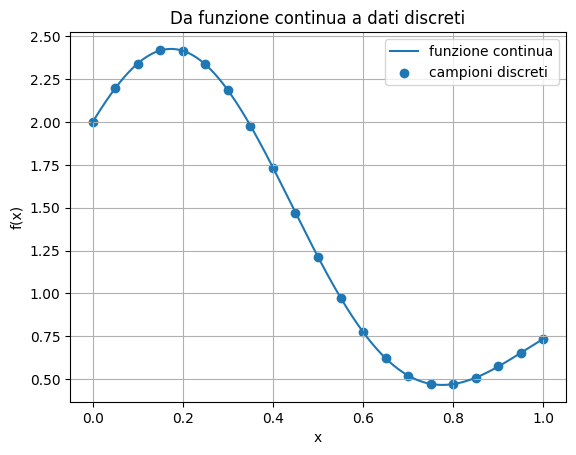

In [12]:
# Esempio: una funzione continua campionata su una griglia finita.

def f_continua(x):
    return np.exp(-x) * (np.sin(2*np.pi*x) + 2)

x_fine = np.linspace(0, 1, 600)
x_grid = np.linspace(0, 1, 21)

plt.figure()
plt.plot(x_fine, f_continua(x_fine), label="funzione continua")
plt.scatter(x_grid, f_continua(x_grid), label="campioni discreti")
plt.title("Da funzione continua a dati discreti")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

### Perché l'errore è inevitabile

Il risultato di un calcolo numerico interessante è quasi sempre approssimato.

Le cause principali sono:

1. **errore nel modello o nei dati**;
2. **errore di discretizzazione**;
3. **errore di convergenza**;
4. **errore di arrotondamento**.

L'obiettivo non è eliminare completamente l'errore, ma controllarlo e mantenerlo entro una soglia accettabile.

## Misurare l'errore

**Errore assoluto**

Sia $u$ una quantità esatta e sia $v$ una sua approssimazione.

L'errore assoluto è

$$
|u-v|.
$$

Misura la distanza diretta fra valore esatto e valore approssimato.

È utile quando la scala del problema è nota o quando il valore esatto può essere vicino a zero.

 **Errore relativo**

Se $u\neq 0$, l'errore relativo è

$$
\frac{|u-v|}{|u|}.
$$

Misura l'errore rispetto alla scala del valore esatto.

L'errore relativo è spesso più informativo dell'errore assoluto, soprattutto quando i valori possono avere grandezze molto diverse.

In [13]:
examples = [
    (1.0, 0.99),
    (1.0, 1.01),
    (-1.5, -1.2),
    (100.0, 99.99),
    (100.0, 99.0),
    (1e8, 1e8 - 1),
    (1e-8, 2e-8),
]

print(f"{'u esatto':>14} {'v appross.':>14} {'err. assoluto':>16} {'err. relativo':>16}")
for u, v in examples:
    abs_err = abs(u - v)
    rel_err = abs_err / abs(u) if u != 0 else np.nan
    print(f"{u:14.6g} {v:14.6g} {abs_err:16.6g} {rel_err:16.6g}")

      u esatto     v appross.    err. assoluto    err. relativo
             1           0.99             0.01             0.01
             1           1.01             0.01             0.01
          -1.5           -1.2              0.3              0.2
           100          99.99             0.01           0.0001
           100             99                1             0.01
         1e+08          1e+08                1            1e-08
         1e-08          2e-08            1e-08                1




Se $|u|$ è molto piccolo, l'errore relativo può diventare molto grande o poco significativo.

Per questo motivo, in molti algoritmi si usano criteri misti, per esempio:

$$
|u-v|\le \mathrm{atol}+\mathrm{rtol}|u|.
$$

Qui:

- `atol` è una tolleranza assoluta;
- `rtol` è una tolleranza relativa.

In [14]:
def errore_misto(u, v, atol=1e-12, rtol=1e-12):
    return abs(u - v) <= atol + rtol * abs(u)

tests = [
    (1.0, 1.0 + 1e-13),
    (1e8, 1e8 + 1e-3),
    (1e-14, 0.0),
]

for u, v in tests:
    print("u =", u, "v =", v, "vicini?", errore_misto(u, v))

u = 1.0 v = 1.0000000000001 vicini? True
u = 100000000.0 v = 100000000.001 vicini? False
u = 1e-14 v = 0.0 vicini? True


## Rappresentazione dei numeri in base $\beta$

Fissato un numero $\beta$ intero maggiore di 1, rappresentiamo nella base $\beta$ un numero reale qualunque $\alpha$.

*rappresentazione di tipo misto*

$$  \alpha=(\alpha_0\alpha_1\alpha_2\ldots\alpha_p .
       \alpha_{p+1}\alpha_{p+1}\ldots)_\beta
              =\sum_{k=0}^p\alpha_k\beta^{p-k} +
    \sum_{k=1}^\infty\alpha_{k+p}\beta^{-k}
   $$

*rappresentazione normalizzata*

$$ \alpha=\pm(.\alpha_1\alpha_2\ldots)\beta^{p}$$




## Rappresentazione dei numeri interi

**Conversione da base 10 a base $\beta=2$**

![alt-text](immagini_sorgente/fig1.png)

<p align="center">
  <img src="immagini_sorgente\fig1.png"  width="800">
</p>

- Si ottengono le cifre di rappresentazione di $\alpha$ in base $\beta$ dalla meno significativa alla più significativa.
- Pertanto, scrivendo i resti delle divisioni nell'ordine inverso a quello in cui sono stati ottenuti si
ottiene la rappresentazione in forma sintetica di $\alpha$ in base $\beta$.

- Sul calcolatore, il numero è cocnvertito in base 2 ed ogni cifra viene memorizzata in un bit. Con $N$ bit sono rappresentabili i numeri naturali (interi positivi) da $0$ a $2^{N-1}$.

-Per rappresentare un numero intero negativo, si può utilizzare la rappresentazione con modulo e segno in cui il primo bit viene usato per rappresentare il segno e i successivi il modulo. Con questa rappresentazione, il numero 0 ha due possibili rappresentazioni: +0 e -0.


## Rappresentazione di numeri reali

Conversione da base 10 a base $\beta$ di un numro minore di uno, tramite il metodo delle moltiplicazioni successive:

<p align="center">
  <img src="immagini_sorgente\fig12.png"  width="800">
</p>

- Ci si arresta o perchè la parte frazionaria diventa nulla o perchè si è raggiunto un numero di cifre
sufficienti.
- non è detto che se un
numero ha rappresentazione finita in base 10 altrettanto accade in base $\beta$.

**Conversione di un numero reale da base 10 a base $\beta$**

Si convertono separatamente la parte reale e la parte decimale.

Esempio: $\alpha=-25.357$

- Si converte la parte intera $25=(11001)_2$
- Si converte la parte frazionaria    $.357=(.011)_2$
-  $\alpha= =(-11001.011)_2$

**Rappresentazione scientifica normalizzata di un numero reale:**
  
Ogni numero reale $x\in \mathbb{R}$ può essere rappresentato come

$$ x=\pm (0.d_1d_2d_3\ldots )\beta^p = \pm
    \sum_{i=1}^\infty(d_i\beta^{-i})\beta^p $$

dove

- $p$ è un numero intero
-  le cifre $d_i$ verificano le condizioni:

    -  $0\leq d_i \leq \beta-1$
    -  $d_1 \neq 0$ e le $d_i$ non sono tutte uguali a $\beta-1$ a partire da un indice in poi.

- La rappresentazione di $x$ nella forma $\pm (0.d_1d_2d_3\ldots
)\beta^p$ è chiamata **rappresentazione normalizzata**
- Il numero $m = 0.d_1d_2d_3\ldots $ viene detto comunemente la **mantissa** di $x$
- $\beta^p$ la *parte esponente*
-  Il numero $p$ è detto anche **caratteristica** (o esponente) di $x$
-  $\beta$ è detto **base**
- Le $d_i$ sono dette **cifre della rappresentazione**



## Sistema floating point

- A causa della sua capacità finita, un calcolatore non è in grado di rappresentare tutto l'insieme
dei numeri reali. Si pone pertanto il problema di definire, per ogni
$x$ rappresentato nella forma precedente, una sua rappresentazione
approssimata nel calcolatore. 
-  Si tratta di un fatto tecnico, ma con importanti implicazioni nel calcolo numerico.
-  Un metodo divenuto ormai usuale per il calcolo scientifico e
noto come *sistema floating-point* o *virgola mobile*.
- Esso permette la rappresentazione di un
ampio intervallo della retta reale con una distribuzione uniforme
degli errori relativi. L'ampiezza effettiva dell'intervallo dipende
dal particolare calcolatore su cui la procedura è implementata.

Si definisce **insieme dei numeri macchina (floating-point)**
con $t$ cifre significative, base $\beta$ e range $(L,U)$, l'insieme
dei numeri reali definito nel modo seguente

$$\mathbb{F}(\beta,t,L,U)=\Big\{ 0
\Big\}\cup\Big\{x\in\mathbb{R}=\text{sign}(x)\beta^p\sum_{i=1}^td_i\beta^{-i}\Big\}
$$
ove $t$,$\beta$ sono interi positivi con $\beta\geq2$.

 Si ha inoltre:

$$ 0\leq d_i \leq \beta-1, \quad i=1,2,\ldots d_1 \neq 0, \quad L\leq p\leq U$$

I-n rappresentazione posizionale un numero macchina $x \neq 0$ viene
denotato con $x = \pm.d_1d_2\ldots d_t \beta^p$.
-  La maggior parte dei calcolatori ha la possibilità di operare con lunghezze
diverse di $t$, a cui corrispondono, ad esempio, la semplice e la
doppia precisione. 
- E' importante osservare che l'insieme
$\mathbb{F}$ non è un insieme continuo e neppure infinito.



I numeri dell'insieme $\mathbb{F}$ sono ugualmente spaziati
tra le successive potenze di $\beta$, ma non su tutto l'intervallo.

*Esempio* $\beta=2$, $t=3$, $L=-1$, $U=2$.

$$\mathbb{F}=\{0\}\cup\{0.100\times 2^p,  0.101\times 2^p,  0.110\times 2^p, 0.111\times 2^p, \; p=-1,0,1,2\$$

dove 0.100, 0.101, 0.110, 0.

Sono 33 numeri compreso lo zero.

<p align="center">
  <img src="immagini_sorgente\fig22.png"  width="800">
</p>

<p align="center">
  <img src="immagini_sorgente\fig4.png"  width="800">
</p>

Risulta evidente l'aumento dell'ampiezza degli intervalli definiti
dal valore $p$, in ognuno dei quali vengono localizzati i 4 valori
della mantissa; ne risulta di conseguenza una diradazione delle
suddivisioni verso gli estremi sinistro e destro della retta reale.

Le grandezze
fondamentali che defiscono l'insieme dei numeri finiti, oltre alla
base di rappresentazione $\beta$, sono:

-  $L$ e $U$ che definiscono l'ordine di grandezza dei numeri
rappresentabili e in genere $L\sim U$;
- il numero $t$ di cifre della mantissa che fissa la precisione di
  rappresentazione di ogni numero; infatti la retta reale viene suddivisa in
intervalli $[\beta^p; \beta^{p+1}]$ di ampiezza crescente
esponenzialmente con il valore $p$, ed in ognuno di questi
intervalli vengono rappresentati lo stesso numero
$(\beta-1)\beta^{t-1}$ di valori. Si ha quindi una suddivisione
molto densa per valori vicini allo 0 e più rada per valori grandi in
valore assoluto.

- Tutti i numeri
reali all'interno di un sotto-intervallo tra due valori
rappresentabili vengono approssimati da uno dei due estremi, quindi
maggiore è il numero $t$ di cifre della mantissa, minore sarà
l'ampiezza dei sotto-intervalli e quindi migliore l'approssimazione
introdotta. La normalizzazione di numeri floating point causa un
''salto'' intorno allo 0 nell'intervallo dei reali.

- precisione del numero floating point dipende dalla
lunghezza della mantissa

-  Gli $n$ bit (o
posizioni) disponibili per la memorizzazione di un numero finito
vengono suddivisi tra le $t$ cifre della mantissa e l'esponente $p$,  più un bit per il segno del numero.
-  Nel caso della rappresentazione binaria, sarà
sempre $d_1 = 1$, per cui può essere sottointeso senza mai essere
fisicamente rappresentato.

## Rappresentazioni IEEE floating point

Alcune tipiche
rappresentazioni sono:

-  $\mathbb{F}_{(2,24,-128,127)}$ precisione singola: 32 bit. Vengono destinati 24 bit alla mantissa (in
realtà solo 23) e 8 all'esponente ($2^8$ = 256 = U-L+1; con L=-128 e
U=127)
- $\mathbb{F}_{(2,53,-1024,1023)}$ precisione doppia: 64 bit.
  Le cifre della mantissa sono 53 (rappresentati 52 bit) e
dell'esponente 11 ($2^{11}$ = 2048 =U-L+1; con L=-1024 e U=1023)

- Nella codifica IEEE standard esistono anche sequenze di bit per rappresentare i valori
   +0, -0, +$\infty$, -$\infty$, e quantità simboliche chiamate NaN (Not a Number).
   Queste quantità sono utilizzate per gestire ``speciali'' operazioni,
   tipo la radice quadrata di un numero negativo, altrimenti non rappresentabili


<p align="center">
  <img src="immagini_sorgente\fig5.png"  width="800">
</p>


- Si noti che la normalizzazione della mantissa
permette di sfruttare al meglio le cifre disponibili, evitando di
rappresentare esplicitamente gli 0 non significativi. Ad esempio
0.000124 viene rappresentato come $0.124\times10^{-3}$.
- La virgola
quindi non ha una posizione fissa tra la parte intera e quella non,
ma varia; per questo motivo tale rappresentazione è detta
*floating-point* o a *virgola mobile*.


## Rappresentazione di un numero reale in un sistema floating-point

Come
rappresentare un numero reale positivo $x$ in un sistema di numeri
macchina $\mathbb{F}(\beta, t,L,U)$?

- se il numero $x$ è tale che $L \leq p \leq U$ e $d_i = 0$ per $i > t$; allora $x$ è un numero macchina ed è
rappresentato esattamente.
- se $p\notin [L,U]$; il numero non può essere rappresentato
esattamente. Se $p < L$, si dice che si verifica
un underflow; solitamente si assume come valore approssimato del numero $x$ il numero zero.
Se $p > U$ si verifica un overflow e solitamente non si effettua nessuna approssimazione, ma il
sistema di calcolo dà un avvertimento più drastico, come ad esempio, l'arresto del calcolo.

- se la caratteristica $p \in [L,U]$, ma le cifre $d_i$, per $i > t$, non sono tutte nulle.
In questo caso si pone il problema di scegliere un suo rappresentante in $\mathbb{F}$. Tale operazione
viene indicata comunemente come operazione di arrotondamento (rounding), anche se in realtà
possono essere utilizzate tecniche di tipo diverso.

Se il numero è infinito, al numero viene associato il suo float
ottenuto troncando (o arrotondando) la mantissa e viene
rappresentato in memoria il float ottenuto:

$$ x=1.333333\ldots=0.133333\ldots \cdot 10^1=fl(x)=0.133333 \cdot 10^1 $$


## Errori di rappresentazione 

Se un numero $x \in R$ viene rappresentato in un sistema floating-point $\mathbb{F}(\beta, t,L,U)$  e $x$ non appartiene al sistema floating point  si avrà che $fl(x) \neq x$, cioè fra il numero $fl(x)$, associato ad $x$, ed $x$ c'è una differenza che viene detta *errore di rappresentazione di $x$.

Rispetto a tale errore si può dare una stima per eccesso:

**Errore relativo di arrotondamento**  

$$E_r=\frac{|fl(x)-x|}{|x|} < \frac{1}{2}\beta^{1-t}$$

**Errore relativo di troncamento**  

$$E_r=\frac{|fl(x)-x|}{|x|} < \beta^{1-t}$$

La quantità 
$eps = \frac{1}{2}\beta^{1-t}$ è detta **precisione
macchina** nel fissato sistema floating point. 
La sua importanza
numerica è data dalla seguente caratterizzazione: $eps$ è il più
piccolo numero macchina positivo tale che

$$fl(1+eps)>1$$




# Arutmetica floating-point

Le operazioni eseguite sul calcolatore (calcolo numerico) possono essere eseguite solo con
numeri rappresentabili sul calcolatore stesso.
- Poichè $\mathbb{F}$ è un sottoinsieme di $\mathbb{R}$, le usuali operazioni aritmetiche
sono definite anche per operandi in $\mathbb{F}$, ma il loro
risultato, in generale, non sta in $\mathbb{F}$. \item \alert{Il
risultato esatto è arrotondato ad un numero che stia in
$\mathbb{F}$}.

- *Operazione aritmetica reale*:
 $$\cdot \; :\;\mathbb{R}\times\mathbb{R}\rightarrow\mathbb{R}$$

- *operazione floating-point (o di macchina)*: 
$$\odot:\mathbb{F}\times\mathbb{F}\rightarrow\mathbb{F}$$

$$x\odot y = fl(x \cdot y)$$

- Ogni operazione provoca in generale un errore, detto *errore di arrotondamento* (del risultato dell'operazione)

$$\left| \frac{(x\odot y)-(x\cdot y)}{x\cdot y}\right| <  eps$$

**Realizzazione
hardware di un'operazione floating point** (con registro con
precisione estesa) $x \oplus y$

- Eseguo l'operazione esatta $z=x+y$
- Effettuo il troncamento del risultato $x\oplus y=fl(z)$

Non vale la proprietà associativa nell'aritmetica
floating point. 

- Sulla maggior parte dei computer le operazioni aritmetiche (passo 1) sono fatte utilizzando più bit di quelli
utilizzati per memorizzare il risultato.
- Il formato intermedio esteso non è accessibile all'utente, ma viene
memorizzato in un registro interno alla CPU. 
- Una volta che il
calcolo è stato fatto in precisione estesa, il risultato viene
arrotondato alla precisione del risultato (passo 2)

Il risultato di un' operazione in aritmetica floating point puo' essere differente rispetto al risultato della stessa operazion e in  aritmetica esatta.

- Addizione o sottrazione: lo spostamento della mantissa puo causare perdita di cifre o di accuratezza. 
- Moltiplicazione: Il prodotto di due numeri con  $t$-cifre di mantissa ha al piu'
$2t$ cifre, quindi il risultato puo'non essere rappresentabile. 
- Division :Il  quoziente di due numeri con  $t$ cifre di mantissa puo'contenere piu'di $t$ cifre come per esempio la rappresentazione binaria  di 
$1/10$

Esempio: $\beta=10$, $t=6$
	$x=192.403, y=0.635782, \ \ fl(x)=0.192403 \cdot 10^3, \ fl(y)=0.635782\cdot 10^0$

- $z=fl(x)+fl(y)=(0.192403 + 0.000635782)\cdot 10^3 = 0.193038782 \cdot 10^3$
$fl(z)=0.193039 \cdot 10^3$ Le ultime due cifre di  $y$ non influiscono sul risultato.
- $w=fl(x)*fl(y)=(0.635782 \cdot 0.192403)\cdot 10^{3}=0.122326364146\cdot 10^{3}$
$fl(w)=0.122326\cdot 10^{3}$ che elimina la meta' delle cifre..

Esempio 2:

<p align="center">
  <img src="immagini_sorgente\fig8.png"  width="600">
</p>

Il risultato in aritmetica reale puo'non essere rappfresentabile an ch perche'l'esponente $p$ e' esterno al suo range di rappresentazione: 

- $p > U$ Overflow
-  $p<L$ Underflow




## Errori nel calcolo numerico
Nella risoluzione di un problema numerico al calcolatore si possono avere diversi tipi di errore:

- **Errore di misura**, dovuto alle imperfezioni dello strumento di misura dei dati del problema.

- **Errore di troncamento**, quando un procedimento infinito viene realizzato come procedimento finito.
		(esempio: calcolo del valore di una funzione tramite sviluppo in serie).

-  **Errore algoritmico**, dovuto al propagarsi degli errori di arrotondamento sulle singole operazioni in un procedimento complesso.

- **Errore inerente**, dovuto al fatto che i dati di un problema non sempre appartengono all'insieme $\mathbb{F}$
dei numeri rappresentabili e quindi vengono approssimati.



## Proprietà degli algoritmi

## 17. Accuratezza

L'accuratezza misura quanto il risultato calcolato è vicino alla soluzione esatta.

Può essere valutata con:

- errore assoluto;
- errore relativo;
- residuo;
- stime teoriche.

---

Il **residuo** misura quanto bene il risultato calcolato soddisfa l'equazione o il problema di partenza.

Ad esempio, se vogliamo risolvere un'equazione

$$
f(x)=0
$$

e il metodo numerico produce un'approssimazione $\tilde{x}$, il residuo è

$$
r=f(\tilde{x}).
$$

Se $r$ è vicino a zero, significa che $\tilde{x}$ soddisfa quasi l'equazione.

Analogamente, per un sistema lineare

$$
Ax=b,
$$

se $\tilde{x}$ è la soluzione numerica calcolata, il residuo è

$$
r=b-A\tilde{x}.
$$

Un residuo piccolo indica che $A\tilde{x}$ è vicino a $b$, cioè che la soluzione calcolata soddisfa quasi il sistema.

È importante però distinguere tra **errore** e **residuo**:

- l'errore misura quanto $\tilde{x}$ è vicino alla soluzione esatta;
- il residuo misura quanto $\tilde{x}$ soddisfa bene l'equazione.

>In molti casi il residuo è utile perché la soluzione esatta non è nota, mentre il residuo può essere calcolato direttamente.

Un algoritmo numerico dovrebbe permettere di prevedere la grandezza dell'errore atteso.

### Efficienza

L'efficienza riguarda il **costo computazionale**.

Si può misurare con:

- numero di operazioni aritmetiche;
- tempo CPU;
- memoria richiesta;
- accessi alla memoria;
- possibilità di vettorizzazione o parallelizzazione.

Una stima classica conta le operazioni elementari, spesso chiamate **flops**.

### Robustezza

La robustezza misura la capacità di un algoritmo di funzionare bene in situazioni diverse.

Un algoritmo robusto dovrebbe:

- produrre un risultato entro una tolleranza accettabile;
- oppure segnalare chiaramente il fallimento;
- evitare risultati apparentemente validi ma numericamente privi di senso.

Molto software numerico è complesso perché deve gestire casi limite, non perché l'idea matematica di base sia difficile.